# 🍄 Mushroom Edibility: Exploratory Data Analysis
### Classic (1987) vs. Secondary (2020, simulated) Mushroom Datasets

**Important caveat:** this notebook is an educational / machine-learning exploration of two
public benchmark datasets. It is **not** a foraging guide or a real-world mushroom
identification tool. The original UCI documentation for the classic dataset is explicit that
*"there is no simple rule for determining the edibility of a mushroom."* Never use this
analysis, or any ML model trained on it, to decide whether a mushroom is safe to eat.

This is Phase 1 of the larger project plan: **EDA** on both datasets, to be followed by
model benchmarking, a data-scaling experiment, and explainability work.

**Datasets**
- **Classic**: `agaricus-lepiota.data` — 8,124 mushrooms, 22 categorical features, UCI 1987.
- **Secondary**: `secondary_data.csv` — 61,069 *simulated* mushrooms, 20 features (17 categorical,
  3 continuous), generated in 2020 from 173 real species profiles.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations

sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_columns", 50)


In [2]:
# ---- Classic dataset: load + decode 1-letter codes to readable labels ----
COLUMNS = [
    "class", "cap-shape", "cap-surface", "cap-color", "bruises", "odor",
    "gill-attachment", "gill-spacing", "gill-size", "gill-color",
    "stalk-shape", "stalk-root", "stalk-surface-above-ring",
    "stalk-surface-below-ring", "stalk-color-above-ring",
    "stalk-color-below-ring", "veil-type", "veil-color", "ring-number",
    "ring-type", "spore-print-color", "population", "habitat",
]

DECODE = {
    "class": {"e": "edible", "p": "poisonous"},
    "cap-shape": {"b": "bell", "c": "conical", "x": "convex", "f": "flat", "k": "knobbed", "s": "sunken"},
    "cap-surface": {"f": "fibrous", "g": "grooves", "y": "scaly", "s": "smooth"},
    "cap-color": {"n": "brown", "b": "buff", "c": "cinnamon", "g": "gray", "r": "green", "p": "pink",
                  "u": "purple", "e": "red", "w": "white", "y": "yellow"},
    "bruises": {"t": "bruises", "f": "no"},
    "odor": {"a": "almond", "l": "anise", "c": "creosote", "y": "fishy", "f": "foul",
             "m": "musty", "n": "none", "p": "pungent", "s": "spicy"},
    "gill-attachment": {"a": "attached", "d": "descending", "f": "free", "n": "notched"},
    "gill-spacing": {"c": "close", "w": "crowded", "d": "distant"},
    "gill-size": {"b": "broad", "n": "narrow"},
    "gill-color": {"k": "black", "n": "brown", "b": "buff", "h": "chocolate", "g": "gray",
                   "r": "green", "o": "orange", "p": "pink", "u": "purple", "e": "red",
                   "w": "white", "y": "yellow"},
    "stalk-shape": {"e": "enlarging", "t": "tapering"},
    "stalk-root": {"b": "bulbous", "c": "club", "u": "cup", "e": "equal", "z": "rhizomorphs",
                   "r": "rooted", "?": None},
    "stalk-surface-above-ring": {"f": "fibrous", "y": "scaly", "k": "silky", "s": "smooth"},
    "stalk-surface-below-ring": {"f": "fibrous", "y": "scaly", "k": "silky", "s": "smooth"},
    "stalk-color-above-ring": {"n": "brown", "b": "buff", "c": "cinnamon", "g": "gray", "o": "orange",
                                "p": "pink", "e": "red", "w": "white", "y": "yellow"},
    "stalk-color-below-ring": {"n": "brown", "b": "buff", "c": "cinnamon", "g": "gray", "o": "orange",
                                "p": "pink", "e": "red", "w": "white", "y": "yellow"},
    "veil-type": {"p": "partial", "u": "universal"},
    "veil-color": {"n": "brown", "o": "orange", "w": "white", "y": "yellow"},
    "ring-number": {"n": "none", "o": "one", "t": "two"},
    "ring-type": {"c": "cobwebby", "e": "evanescent", "f": "flaring", "l": "large",
                  "n": "none", "p": "pendant", "s": "sheathing", "z": "zone"},
    "spore-print-color": {"k": "black", "n": "brown", "b": "buff", "h": "chocolate", "r": "green",
                           "o": "orange", "u": "purple", "w": "white", "y": "yellow"},
    "population": {"a": "abundant", "c": "clustered", "n": "numerous", "s": "scattered",
                   "v": "several", "y": "solitary"},
    "habitat": {"g": "grasses", "l": "leaves", "m": "meadows", "p": "paths",
                "u": "urban", "w": "waste", "d": "woods"},
}

classic = pd.read_csv("/mnt/user-data/uploads/agaricus-lepiota.data", header=None,
                       names=COLUMNS, na_values="?")
for col, mapping in DECODE.items():
    classic[col] = classic[col].map(mapping)

print("Classic dataset shape:", classic.shape)
classic.head()


Classic dataset shape: (8124, 23)


,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,stalk-shape,stalk-root,stalk-surface-above-ring,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,poisonous,convex,smooth,brown,bruises,pungent,free,close,narrow,black,enlarging,equal,smooth,smooth,white,white,partial,white,one,pendant,black,scattered,urban
1,edible,convex,smooth,yellow,bruises,almond,free,close,broad,black,enlarging,club,smooth,smooth,white,white,partial,white,one,pendant,brown,numerous,grasses
2,edible,bell,smooth,white,bruises,anise,free,close,broad,brown,enlarging,club,smooth,smooth,white,white,partial,white,one,pendant,brown,numerous,meadows
3,poisonous,convex,scaly,white,bruises,pungent,free,close,narrow,brown,enlarging,equal,smooth,smooth,white,white,partial,white,one,pendant,black,scattered,urban
4,edible,convex,smooth,gray,no,none,free,crowded,broad,black,tapering,equal,smooth,smooth,white,white,partial,white,one,evanescent,brown,abundant,grasses


In [3]:
# ---- Secondary dataset: load (semicolon-delimited) ----
secondary = pd.read_csv("/mnt/user-data/uploads/secondary_data.csv", sep=";")
secondary["class"] = secondary["class"].map({"e": "edible", "p": "poisonous"})
print("Secondary dataset shape:", secondary.shape)
secondary.head()


Secondary dataset shape: (61069, 21)


,class,cap-diameter,cap-shape,cap-surface,cap-color,does-bruise-or-bleed,gill-attachment,gill-spacing,gill-color,stem-height,stem-width,stem-root,stem-surface,stem-color,veil-type,veil-color,has-ring,ring-type,spore-print-color,habitat,season
0,poisonous,15.26,x,g,o,f,e,NaN,w,16.95,17.09,s,y,w,u,w,t,g,NaN,d,w
1,poisonous,16.60,x,g,o,f,e,NaN,w,17.99,18.19,s,y,w,u,w,t,g,NaN,d,u
2,poisonous,14.07,x,g,o,f,e,NaN,w,17.80,17.74,s,y,w,u,w,t,g,NaN,d,w
3,poisonous,14.17,f,h,e,f,e,NaN,w,15.77,15.98,s,y,w,u,w,t,p,NaN,d,w
4,poisonous,14.64,x,h,o,f,e,NaN,w,16.53,17.20,s,y,w,u,w,t,p,NaN,d,w


## 1. Class balance

Both datasets are binary classification problems (edible vs. poisonous). A first EDA question
is simply: how balanced are they?

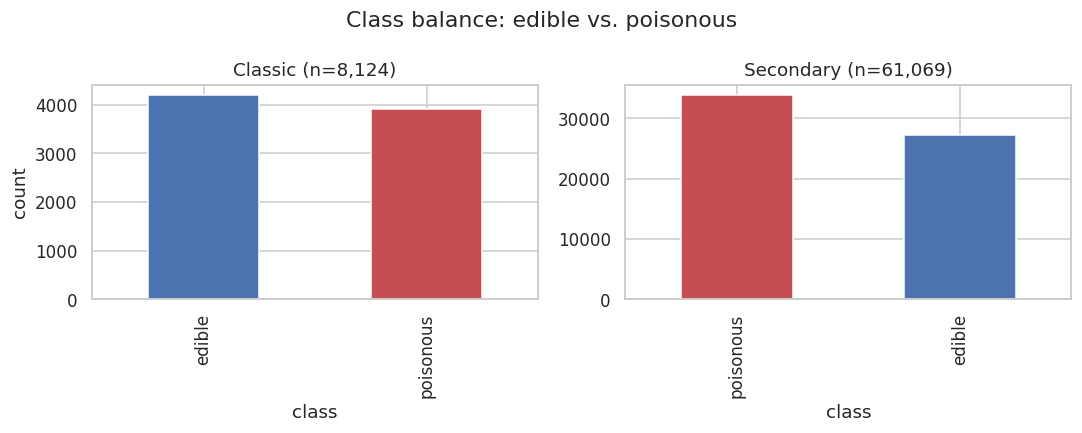

Classic: edible=4208 (51.8%), poisonous=3916 (48.2%)


Secondary: poisonous=33888 (55.5%), edible=27181 (44.5%)


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

classic["class"].value_counts().plot.bar(ax=axes[0], color=["#4C72B0", "#C44E52"])
axes[0].set_title(f"Classic (n={len(classic):,})")
axes[0].set_ylabel("count")

secondary["class"].value_counts().plot.bar(ax=axes[1], color=["#C44E52", "#4C72B0"])
axes[1].set_title(f"Secondary (n={len(secondary):,})")

plt.suptitle("Class balance: edible vs. poisonous")
plt.tight_layout()
plt.show()

for name, df in [("Classic", classic), ("Secondary", secondary)]:
    counts = df["class"].value_counts()
    pct = df["class"].value_counts(normalize=True) * 100
    print(f"{name}: " + ", ".join(f"{k}={v} ({pct[k]:.1f}%)" for k, v in counts.items()))


Both datasets are close to balanced, which is convenient for modeling — accuracy alone
won't be misleading, though we'll still track precision/recall/F1 given that a false "edible"
prediction is far costlier than a false "poisonous" one.

## 2. Missing data

The classic dataset has missingness in a single column (`stalk-root`). The secondary dataset —
being simulated and mixing 173 species profiles — has much more structural missingness, which
itself is worth understanding before modeling (e.g., "no veil" isn't really *missing*, it's a
valid biological state that the encoding represents as NaN).

In [5]:
missing_classic = classic.isna().mean().mul(100).round(1)
missing_classic = missing_classic[missing_classic > 0].sort_values(ascending=False)
print("Classic — columns with missing values (%):")
print(missing_classic)


Classic — columns with missing values (%):
stalk-root    30.5
dtype: float64


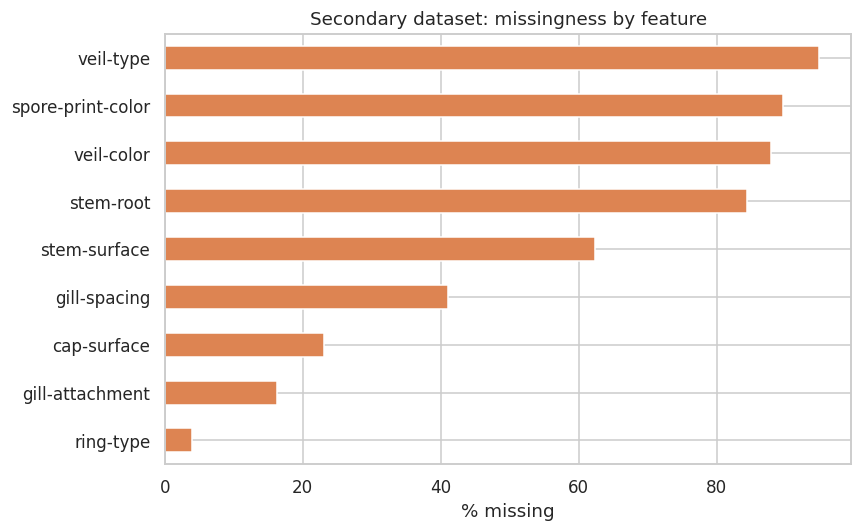

veil-type            94.8
spore-print-color    89.6
veil-color           87.9
stem-root            84.4
stem-surface         62.4
gill-spacing         41.0
cap-surface          23.1
gill-attachment      16.2
ring-type             4.0
dtype: float64


In [6]:
missing_secondary = secondary.isna().mean().mul(100).round(1).sort_values(ascending=False)
missing_secondary = missing_secondary[missing_secondary > 0]

plt.figure(figsize=(8, 5))
missing_secondary.plot.barh(color="#DD8452")
plt.gca().invert_yaxis()
plt.xlabel("% missing")
plt.title("Secondary dataset: missingness by feature")
plt.tight_layout()
plt.show()

print(missing_secondary)


This is a genuinely useful difference between the two datasets for the planned modeling
phase: several secondary-dataset columns (`veil-type`, `spore-print-color`, `stem-root`,
`veil-color`) are missing on 50%+ of rows. That will shape preprocessing choices (e.g.,
treating "missing" itself as an informative category rather than imputing) and gives a
natural experiment for **"how do missing values affect model performance?"** in Phase 2.

## 3. Categorical features vs. class — classic dataset

The classic dataset's own documentation claims `odor` alone gets ~98.5% accuracy. Let's check
that visually, alongside a couple of other strong candidates (`spore-print-color`, `gill-color`).

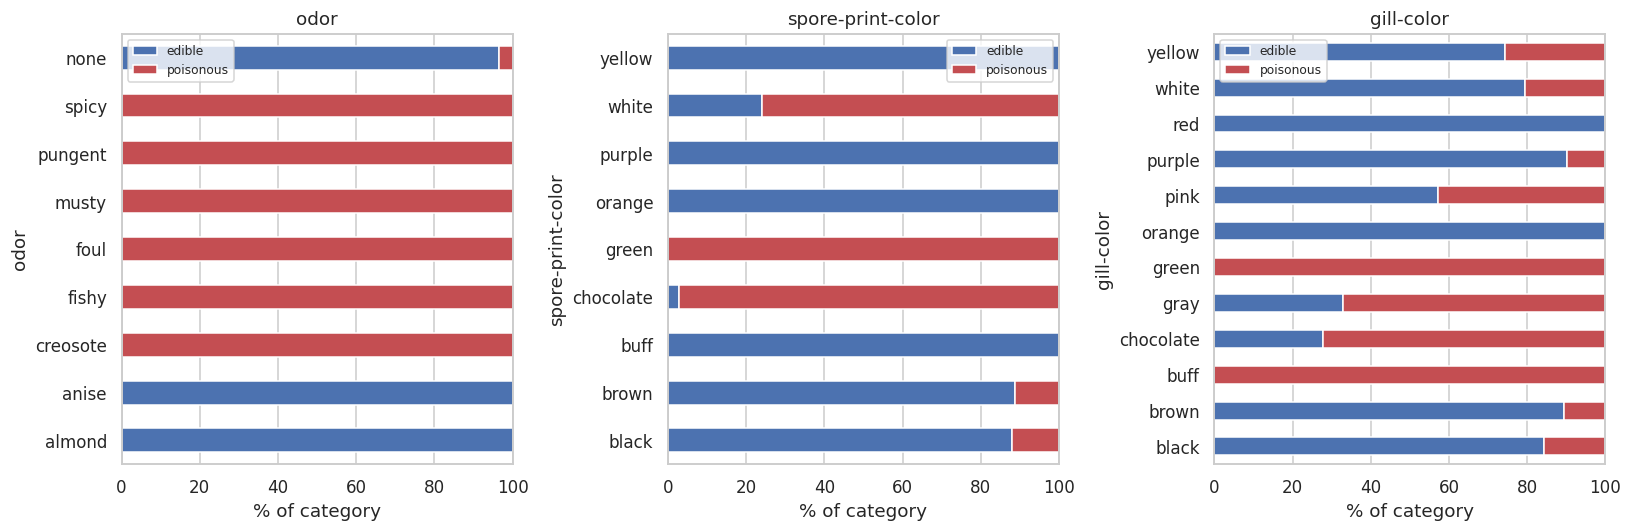

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, feat in zip(axes, ["odor", "spore-print-color", "gill-color"]):
    ct = pd.crosstab(classic[feat], classic["class"], normalize="index") * 100
    ct = ct.loc[ct.sum(axis=1).sort_values(ascending=False).index]
    ct.plot.barh(stacked=True, ax=ax, color=["#4C72B0", "#C44E52"])
    ax.set_xlabel("% of category")
    ax.set_title(feat)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


`odor` is dramatic: categories like *foul*, *fishy*, *spicy*, *pungent*, *creosote*, and
*musty* are essentially 100% poisonous, while *almond* and *anise* are 100% edible. `none` is
mixed but still mostly edible. This single feature is close to a lookup table for this
particular dataset — worth flagging as a modeling and explainability angle (a model that
leans entirely on `odor` will look "too easy" and is a good prompt to discuss the dataset's
known limitations as a stand-in for real foraging).

/tmp/ipykernel_144/1005225072.py:9: RuntimeWarning: invalid value encountered in scalar divide
  return np.sqrt((chi2 / n) / (min(r - 1, k - 1)))


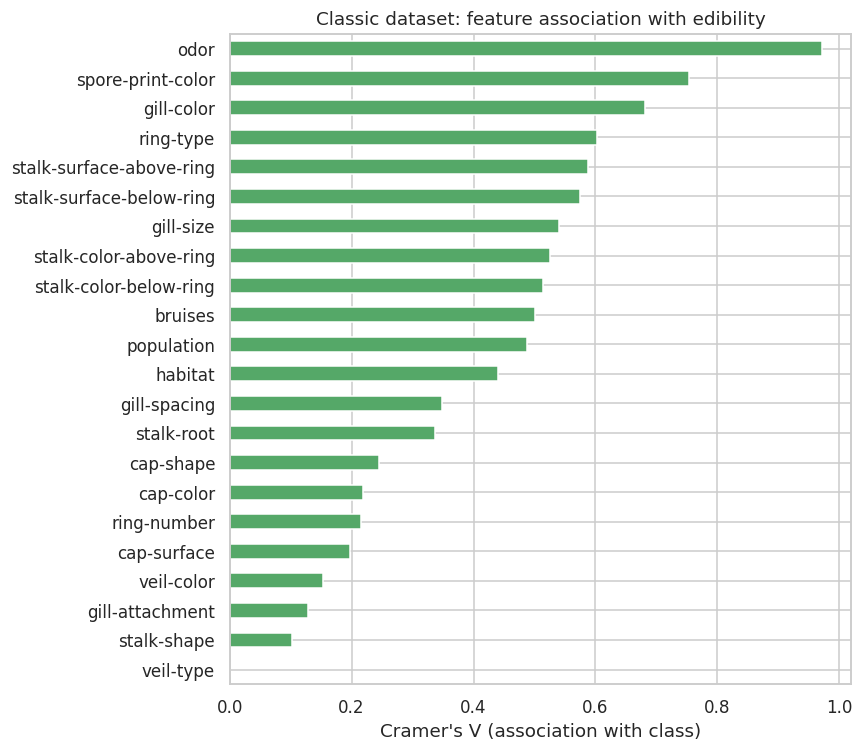

odor                        0.971005
spore-print-color           0.752645
gill-color                  0.680830
ring-type                   0.603271
stalk-surface-above-ring    0.587944
stalk-surface-below-ring    0.574837
gill-size                   0.539758
stalk-color-above-ring      0.524850
stalk-color-below-ring      0.514725
bruises                     0.501280
population                  0.487376
habitat                     0.440136
gill-spacing                0.348052
stalk-root                  0.336284
cap-shape                   0.245571
cap-color                   0.218427
ring-number                 0.214772
cap-surface                 0.196925
veil-color                  0.153421
gill-attachment             0.128424
stalk-shape                 0.101770
veil-type                        NaN
dtype: float64

In [8]:
# Quantify association strength for every categorical feature using Cramer's V
from scipy.stats import chi2_contingency

def cramers_v(x, y):
    ct = pd.crosstab(x, y)
    chi2 = chi2_contingency(ct)[0]
    n = ct.sum().sum()
    r, k = ct.shape
    return np.sqrt((chi2 / n) / (min(r - 1, k - 1)))

assoc = {}
for col in classic.columns.drop("class"):
    sub = classic[[col, "class"]].dropna()
    assoc[col] = cramers_v(sub[col], sub["class"])

assoc = pd.Series(assoc).sort_values(ascending=False)

plt.figure(figsize=(8, 7))
assoc.plot.barh(color="#55A868")
plt.gca().invert_yaxis()
plt.xlabel("Cramer's V (association with class)")
plt.title("Classic dataset: feature association with edibility")
plt.tight_layout()
plt.show()

assoc


## 4. Numeric features vs. class — secondary dataset

Only the secondary dataset has continuous measurements: `cap-diameter`, `stem-height`,
`stem-width`. Do they separate edible from poisonous mushrooms on their own?

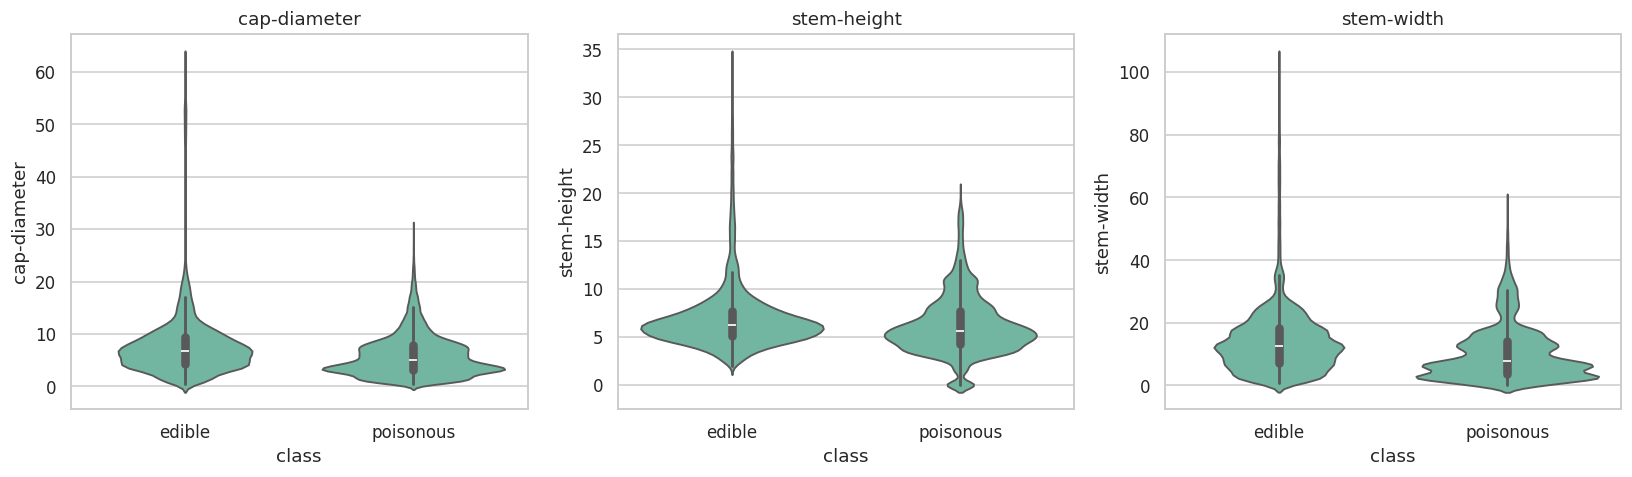

class                     edible     poisonous
cap-diameter count  27181.000000  33888.000000
             mean       7.798696      5.879763
             std        6.373404      3.966391
             min        0.530000      0.380000
             25%        4.290000      3.040000
             50%        6.710000      4.980000
             75%        9.410000      7.850000
             max       62.340000     30.340000
stem-height  count  27181.000000  33888.000000
             mean       7.039077      6.214554
             std        3.583433      3.140778
             min        2.000000      0.000000
             25%        5.080000      4.210000
             50%        6.240000      5.630000
             75%        7.740000      7.740000
             max       33.920000     20.190000
stem-width   count  27181.000000  33888.000000
             mean      14.361084     10.375463
             std       11.042703      8.753975
             min        0.740000      0.000000
             25%        7.130000      3.580000
             50%       12.590000      7.660000
             75%       18.390000     14.340000
             max      103.910000     58.950000

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, feat in zip(axes, ["cap-diameter", "stem-height", "stem-width"]):
    sns.violinplot(data=secondary, x="class", y=feat, ax=ax, order=["edible", "poisonous"])
    ax.set_title(feat)
plt.tight_layout()
plt.show()

secondary.groupby("class")[["cap-diameter", "stem-height", "stem-width"]].describe().T


The distributions overlap heavily between classes — none of the three numeric features
is anywhere near as separating as `odor` was in the classic dataset. That's a useful,
concrete finding for Phase 2's question *"do continuous measurements improve predictions?"*:
on their own, probably not much; they may still add value in combination with categorical
features and nonlinear models.

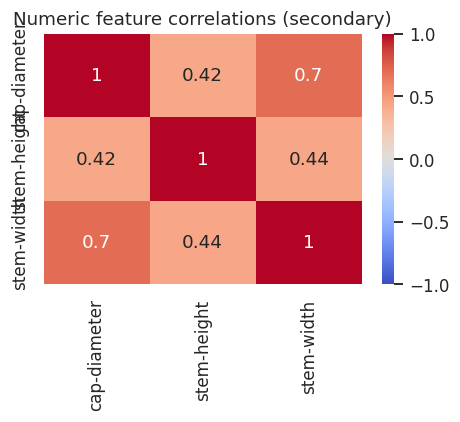

In [10]:
# correlation among the numeric features themselves
plt.figure(figsize=(4.5, 4))
sns.heatmap(secondary[["cap-diameter", "stem-height", "stem-width"]].corr(),
            annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Numeric feature correlations (secondary)")
plt.tight_layout()
plt.show()


## 5. Categorical features vs. class — secondary dataset

Repeat the Cramer's V ranking for the secondary dataset's categorical features, to compare
which characteristics matter most in the newer, larger, more varied dataset.

/tmp/ipykernel_144/4275043970.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols_secondary = secondary.select_dtypes(include="object").columns.drop("class")


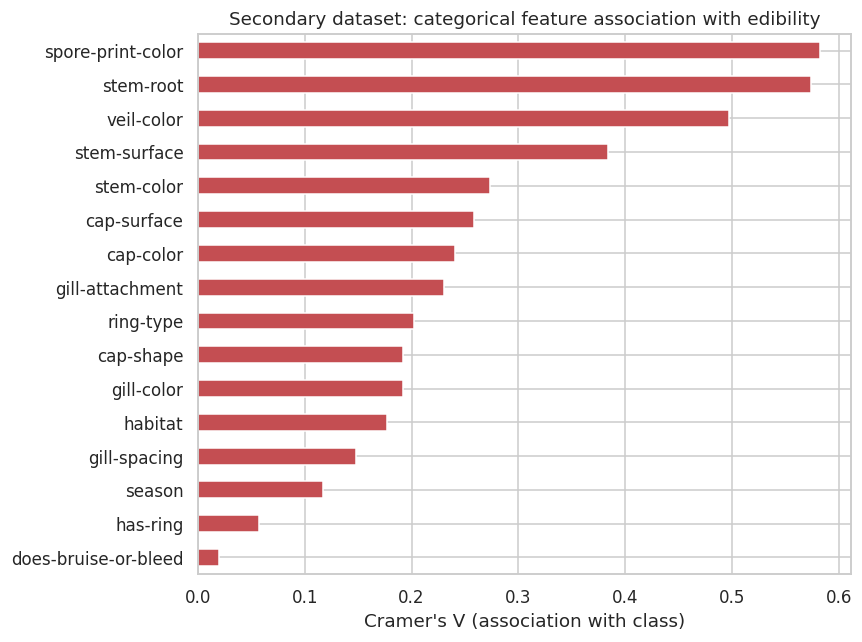

spore-print-color       0.582001
stem-root               0.573944
veil-color              0.496936
stem-surface            0.383930
stem-color              0.273194
cap-surface             0.258414
cap-color               0.240801
gill-attachment         0.230002
ring-type               0.202282
cap-shape               0.192253
gill-color              0.191735
habitat                 0.176726
gill-spacing            0.147708
season                  0.117074
has-ring                0.057521
does-bruise-or-bleed    0.019845
dtype: float64

In [11]:
cat_cols_secondary = secondary.select_dtypes(include="object").columns.drop("class")

assoc_secondary = {}
for col in cat_cols_secondary:
    sub = secondary[[col, "class"]].dropna()
    if sub[col].nunique() < 2:
        continue
    assoc_secondary[col] = cramers_v(sub[col], sub["class"])

assoc_secondary = pd.Series(assoc_secondary).sort_values(ascending=False)

plt.figure(figsize=(8, 6))
assoc_secondary.plot.barh(color="#C44E52")
plt.gca().invert_yaxis()
plt.xlabel("Cramer's V (association with class)")
plt.title("Secondary dataset: categorical feature association with edibility")
plt.tight_layout()
plt.show()

assoc_secondary


Notably, the secondary dataset has **no `odor` column at all** — one of the classic
dataset's most powerful (and most "too easy") features simply doesn't exist here. This alone
means the two datasets are not directly comparable apples-to-apples, and it's a genuinely
interesting angle for Phase 3/4: the secondary dataset forces models to rely on a *combination*
of weaker signals rather than one dominant categorical feature, which should make it a more
realistic (and harder) benchmark.

## 6. Comparing shared features across datasets

Both datasets share several raw feature names (`cap-shape`, `cap-color`, `cap-surface`,
`gill-attachment`, `gill-spacing`, `gill-color`, `habitat`, `ring-type`,
`spore-print-color`, `veil-type`, `veil-color`, `has-ring`/`bruises`-style flags). Let's check
whether their *value distributions* look similar, since the secondary data is simulated from
173 species rather than 23.

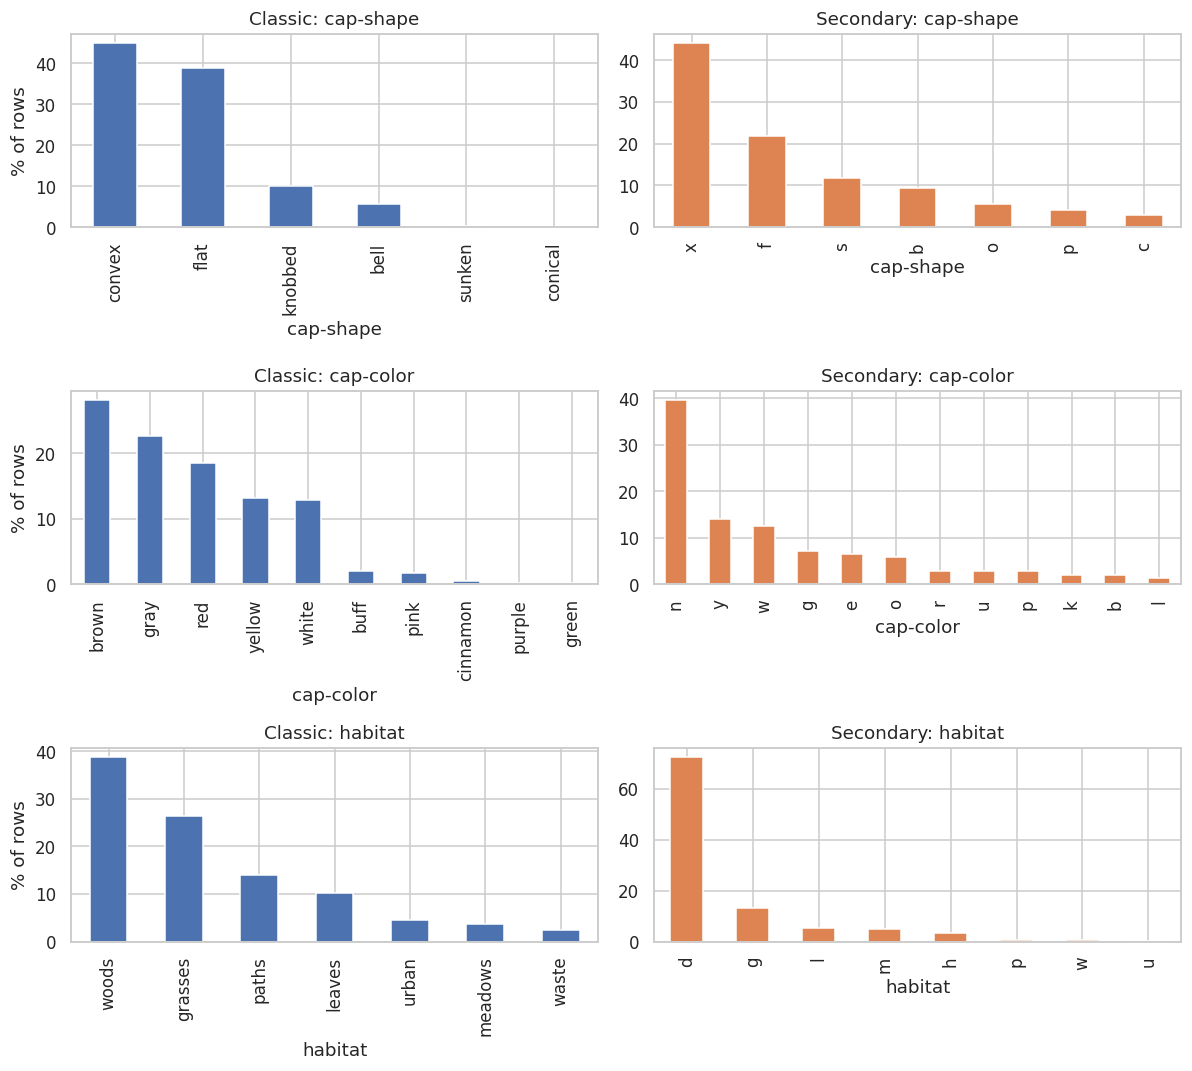

In [12]:
shared = ["cap-shape", "cap-color", "habitat"]

fig, axes = plt.subplots(len(shared), 2, figsize=(11, 3.3 * len(shared)))
for i, feat in enumerate(shared):
    classic[feat].value_counts(normalize=True).mul(100).sort_values(ascending=False).plot.bar(
        ax=axes[i, 0], color="#4C72B0")
    axes[i, 0].set_title(f"Classic: {feat}")
    axes[i, 0].set_ylabel("% of rows")

    secondary[feat].value_counts(normalize=True).mul(100).sort_values(ascending=False).plot.bar(
        ax=axes[i, 1], color="#DD8452")
    axes[i, 1].set_title(f"Secondary: {feat}")

plt.tight_layout()
plt.show()


The secondary dataset shows a wider, more even spread of categories for `cap-shape` and
`cap-color` — consistent with it being simulated from 173 species (vs. 23 in the classic set)
and including an explicit `others`/`o` category the classic set lacks. `habitat` distributions
look broadly similar in shape, though `woods` dominates less in the secondary data.

Two features exist **only** in the secondary dataset and have no classic-dataset counterpart
at all: **`season`** and the three **continuous measurements**. These are exactly the
"new information" angles the project plan calls out.

<Figure size 660x440 with 0 Axes>

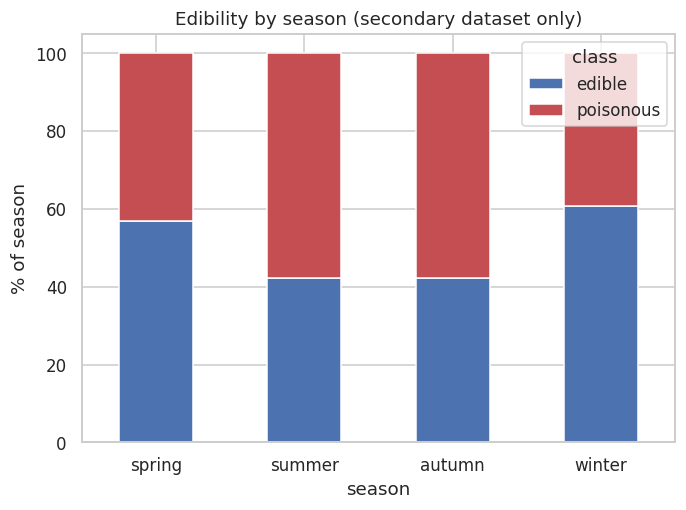

In [13]:
plt.figure(figsize=(6, 4))
ct = pd.crosstab(secondary["season"], secondary["class"], normalize="index") * 100
ct = ct.loc[["s", "u", "a", "w"]].rename(index={"s": "spring", "u": "summer", "a": "autumn", "w": "winter"})
ct.plot.bar(stacked=True, color=["#4C72B0", "#C44E52"])
plt.ylabel("% of season")
plt.title("Edibility by season (secondary dataset only)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 7. Summary of EDA findings

- **Class balance:** both datasets are close to 50/50 edible vs. poisonous — accuracy is a
  reasonable metric, though precision/recall/F1 still matter given asymmetric real-world costs.
- **Missing data:** the classic dataset has one column with missing values (`stalk-root`,
  ~30%). The secondary dataset has much heavier, structural missingness across several
  columns (up to ~95% for `veil-type`) — likely reflecting genuinely absent anatomical
  structures rather than data-collection gaps. This needs a deliberate handling strategy
  before modeling.
- **Strongest single predictor:** `odor` in the classic dataset is an extremely strong,
  almost deterministic signal — a good hook for the "why did the model decide this" /
  explainability phase, and a caveat that classic-dataset performance may look artificially
  easy.
- **The secondary dataset has no `odor` field**, and its numeric measurements
  (`cap-diameter`, `stem-height`, `stem-width`) show heavy class overlap on their own — so no
  single secondary-dataset feature is nearly as separating as `odor` is in the classic set.
  This sets up an interesting Phase 2 question: can model *combinations* of weaker features
  match the classic dataset's near-perfect separability?
- **Distributional differences:** shared categorical features (`cap-shape`, `cap-color`,
  `habitat`) show broader category spread in the secondary dataset, consistent with it being
  simulated from 173 species rather than 23.
- **Secondary-only features** (`season`, and the three continuous measurements) are new
  information not available in the classic dataset at all.

**Suggested next step:** Phase 2 — build a standardized preprocessing + modeling pipeline
(Logistic Regression, Decision Tree, Random Forest, and a boosting model) applied to both
datasets, so performance, feature importance, and error patterns can be compared on equal
footing.